# Portfolio 3 - Multi-Agent Reinforcement Learning (Atari Warlords)

**Vak:** Autonomous Systems · De Haagse Hogeschool

Dit notebook vormt zowel het **rapport** als de **reproduceerbare pijplijn**. Wij trainen een Deep RL-agent die in de multi-agent Atari-omgeving Warlords concurreert met drie andere agenten, en wij vergelijken deze met twee baselines. De eindoplevering bestaat uit per-hoek getrainde **independent PPO-policies** (IPPO) en, ter vergelijking, een **hoek-robuust league-beleid** (random -> rule-based -> self-play).

> **Uitvoeren:** dit notebook draait lokaal op Linux/WSL2 met een NVIDIA GPU, of in Google Colab (GPU-runtime). De Atari-backend `multi_agent_ale_py` heeft geen Windows-wheels; native Windows werkt niet. De totale rekentijd bedraagt bij volledige instellingen ongeveer 7–8 uur op een laptop-GPU (RTX 5050 / 20 CPU-cores); met de "snel"-instellingen ongeveer 30 minuten voor demonstratiedoeleinden.

| | |
|---|---|
| **Project** | Multi-Agent Reinforcement Learning |
| **Omgeving** | `pettingzoo.atari.warlords_v3` (RAM-observaties) |
| **Algoritme** | PPO (Proximal Policy Optimization) via Stable-Baselines3 |
| **MARL-strategie** | Independent PPO (IPPO) per hoek + hoek-robuust league-curriculum |
| **Evaluatie** | Win-rate tegen een random- en een rule-based baseline |

> In dit project trainen wij een reinforcement-learning agent voor het Atari-spel Warlords. In dit spel verdedigen vier spelers elk hun eigen kasteel in een hoek.

> Als basisalgoritme gebruiken wij PPO (Proximal Policy Optimization). Omdat alle vier de hoeken dezelfde globale RAM waarnemen, trainen wij **independent learners**: een afzonderlijk PPO-beleid per hoek, met per generatie bevroren tegenstanders.

> Daarnaast onderzoeken wij een **hoek-robuust beleid** dat via een league-curriculum tegen steeds sterkere tegenstanders leert (random -> rule-based -> self-play).

> Het doel van het project is een agent te ontwikkelen die aantoonbaar beter presteert dan een random- en een rule-based baseline, en uiteindelijk sterk genoeg is om mee te doen aan een toernooi met de hele klas.

## Inhoudsopgave

1. [Inleiding & Probleemanalyse](#inleiding)
   - 1.1 [De omgeving: Warlords](#omgeving)
   - 1.2 [Waarom dit een multi-agent-probleem is](#multiagent)
   - 1.3 [Een cruciale observatie over de RAM](#ram)
   - 1.4 [Keuze van algoritme en trainingsstrategie](#algoritme)
   - 1.5 [Baseline](#baseline-intro)
2. [Setup](#setup)
3. [De omgeving verkennen](#verkennen)
4. [Baselines](#baselines)
5. [Methode: van multi-agent naar trainbaar single-agent](#methode)
6. [Training (IPPO)](#training)
7. [Resultaten & Discussie](#resultaten)
   - 7.1 [Leercurves](#leercurves)
   - 7.2 [RL vs. baseline](#rlvsbaseline)
   - 7.4 [Een wedstrijd opnemen](#video)
8. [Hyperparameter-experimenten](#hyperparameters)
   - 8.2 [Entropy-coëfficiënt](#entropy)
9. [Toernooi-agent: hoek-robuust league-beleid](#toernooi)
   - 9.1 [Trainingsstrategie](#strategie)
   - 9.2 [Reward shaping en hyperparameters](#rewardhyper)
   - 9.4 [Leercurve van de league](#leercurve-league)
   - 9.5 [Toernooi-evaluatie](#evaluatie)
   - 9.7 [Analyse: waarom het hoek-robuuste beleid faalt](#analyse)
10. [Conclusie & Reflectie](#conclusie)
- [Referentielijst](#referenties)

<a id="inleiding"></a>
## 1. Inleiding & Probleemanalyse

Reinforcement Learning (RL) is een tak van machine learning waarin een agent leert door te handelen in een omgeving en daar feedback op te krijgen (Sutton & Barto, 2018). In de afgelopen jaren is RL sterk gegroeid dankzij de combinatie met diepe neurale netwerken (Deep RL). Bekende successen zijn AlphaGo (Silver et al., 2018) en OpenAI Five in Dota 2 (Berner et al., 2019). De meeste van deze successen spelen zich af in omgevingen met een agent of met vaste teams. Multi-Agent Reinforcement Learning (MARL), waarbij meerdere agenten tegelijk leren en elkaar beïnvloeden, is veel complexer, omdat de omgeving voor elke agent voortdurend verandert doordat de andere agenten ook leren (Li et al., 2025).

Dit portfolio-project gaat precies over dat probleem. Wij bouwen een agent voor het Atari-spel Warlords, dat beschikbaar is in de PettingZoo-bibliotheek (Terry et al., 2021). Warlords is een spel met vier spelers die elk een fort verdedigen. De beloning is eenvoudig: +1 bij winst, −1 bij verlies en 0 voor alle tussenliggende stappen. Deze late en schaarse beloning maakt het leren moeilijk. Daarnaast trainen wij via self-play: de agent speelt tegen eerdere versies van zichzelf, wat extra aandacht vraagt voor de stabiliteit van het leerproces (Berner et al., 2019).

<a id="omgeving"></a>
### 1.1 De omgeving: Warlords
Warlords is een Atari-spel met **vier spelers** die elk een kasteel in een hoek verdedigen met een paddle. Een bal stuitert rond; wordt een kasteel geraakt, dan valt de betreffende speler af. De laatste speler die overblijft, wint. In de PettingZoo-implementatie (`warlords_v3`) betekent dit:

| Eigenschap | Waarde |
|---|---|
| Agenten | `first_0`, `second_0`, `third_0`, `fourth_0` (4) |
| Actieruimte | `Discrete(6)`: 0=noop, 1=fire, 2=up, 3=right, 4=left, 5=down |
| Observatie (`obs_type="ram"`) | 128 bytes console-RAM (`uint8`, 0–255) |
| Beloning | **spaarzaam/terminaal**: −1 wanneer het eigen kasteel valt, +1 wanneer de speler als laatste overblijft |

Dit is een **competitieve, gemengde multi-agent-omgeving**: de agenten delen een omgeving, maar hebben tegengestelde belangen.

<a id="multiagent"></a>
### 1.2 Waarom dit een multi-agent-probleem is
Vanuit het perspectief van een agent vormen de andere drie agenten onderdeel van de omgeving. Omdat die anderen óók leren en hun gedrag veranderen, is de omgeving **niet-stationair**: de optimale strategie verschuift terwijl de tegenstanders beter worden (Busoniu et al., 2008; Lowe et al., 2017). Een goede aanpak moet hier expliciet rekening mee houden.

<a id="ram"></a>
### 1.3 Een cruciale observatie over de RAM
In `warlords_v3` ontvangen **alle vier de agenten dezelfde globale 128-byte RAM** (zie `base_atari_env.py`: `{agent: obs for agent in self.agents}`). Er is dus geen hoek-specifieke observatie en geen indicator van wélke hoek een agent bestuurt. Eén enkel gedeeld beleid kan de hoeken daardoor niet uit elkaar houden. Dit motiveert direct onze keuze voor **independent learners**: vier afzonderlijke policies, een per hoek, die elk hun eigen hoek leren verdedigen.

<a id="algoritme"></a>
### 1.4 Keuze van algoritme en trainingsstrategie

Wij hebben een deep reinforcement learning-algoritme nodig dat een stochastisch beleid kan leren in een Atari-omgeving met discrete acties en meerdere agenten. De onderstaande families zetten de belangrijkste afwegingen op een rij:

| Familie | Voorbeeld | Voordelen | Nadelen voor ons |
|---|---|---|---|
| Waarde-gebaseerd | **DQN**, Double-DQN, Rainbow | sample-efficiënt, veel getest op Atari (Mnih et al., 2015) | off-policy met replay-buffer is lastig onder self-play; ε-greedy is zwak in competitief spel; geen stochastisch beleid |
| On-policy actor-critic | **A2C / A3C** (Mnih et al., 2016) | eenvoudig, stabiel | geen trust-region -> grote updates kunnen het beleid laten instorten bij ruis en schaarse beloning |
| Trust-region | **TRPO** (Schulman et al., 2015) | sterke theoretische garanties | tweede-orde; duur; lastig met parameter sharing |
| Clipped policy gradient | **PPO** (Schulman et al., 2017) | eerste-orde, eenvoudig, stochastisch beleid, goed op Atari en in multi-agent | gevoelig voor hyperparameters; vraagt zorg met beloningsschaal (Engstrom et al., 2020) |
| Off-policy actor-critic (continu) | SAC, DDPG, TD3 | sample-efficiënt | gemaakt voor continue acties; geen natuurlijke fit voor Atari |
| Model-based / planning | MuZero, Dreamer | erg sterk op Atari | veel complexer; overkill voor dit project |

Wij kiezen voor de volgende combinatie:

- **Algoritme: PPO** (Proximal Policy Optimization; Schulman et al., 2017). PPO is een on-policy actor-critic methode die door zijn clipped objective stabiel en robuust traint met weinig hyperparameter-tuning. Dat is een groot voordeel in een niet-stationaire multi-agent-setting, waar waarde-gebaseerde methoden (zoals DQN) gevoeliger zijn voor instabiliteit (de Witt et al., 2020).
- **Trainingsstrategie: Independent PPO (IPPO) met generatie-gewijs bevroren tegenstanders.** Elke hoek heeft een eigen PPO-beleid. Wij temmen de niet-stationariteit door de tegenstanders per generatie te bevriezen: elk beleid traint tegen vaste snapshots van de andere drie, waarna alle snapshots worden geüpdatet. Dit is verwant aan fictitious self-play (Heinrich & Silver, 2016) en aan IPPO (de Witt et al., 2020), dat verrassend sterk presteert in competitieve benchmarks.
- **Observatie: RAM.** Het toernooi gebruikt `obs_type="ram"`, en een kleine MLP op 128 bytes traint veel sneller dan een CNN op pixels — ideaal voor de vele benodigde environment-stappen.

PPO is on-policy en gebruikt een rollout-buffer in plaats van experience replay; de gradiënt-updates volgen het clipped surrogate objective (Schulman et al., 2017).

<a id="baseline-intro"></a>
### 1.5 Baseline
Als referentie gebruiken wij twee baselines (opdracht 2a): een **random policy** en een **rule-based policy** die actief de eigen hoek patrouilleert en periodiek vuurt. Beide worden nader uitgewerkt in §4.

<a id="setup"></a>
## 2. Setup

**Lokaal (aanbevolen).** Activeer een venv en installeer eenmalig de dependencies uit `requirements.txt`; download daarna de Atari-ROMs via `AutoROM --accept-license`. De volgende cel valideert dat alles aanwezig is en onderneemt geen actie wanneer dat het geval is.

**Colab.** Verwijder het commentaar voor de pip-install-regel in 2.1 en herstart vervolgens de kernel (Runtime -> Restart) alvorens verder te gaan.

In [1]:
# 2.1 Setup-check. Lokaal: zorg dat je `.venv` is geactiveerd. Colab: uncomment de pip-regel.
# !pip -q install "pettingzoo[atari]>=1.24" "autorom[accept-rom-license]" "stable-baselines3>=2.0.0" imageio imageio-ffmpeg tqdm rich
# !AutoROM --accept-license

import importlib, sys
missing = [m for m in ("pettingzoo", "stable_baselines3", "torch", "imageio", "pandas")
           if importlib.util.find_spec(m) is None]
if missing:
    print("Ontbrekend:", missing,
          "\nLokaal: `pip install -r Portfolio3/requirements.txt` in je venv.")
else:
    import torch
    print(f"OK · Python {sys.version.split()[0]} · torch {torch.__version__} · CUDA {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")

OK · Python 3.12.3 · torch 2.12.1+cu130 · CUDA True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [2]:
# 2.2 Zet werkmap op Portfolio3/ zodat alle relatieve paden kloppen.
import os, sys
if os.path.basename(os.getcwd()) != "Portfolio3":
    for cand in ["Portfolio3", "adsai-autonomous-systems/Portfolio3"]:
        if os.path.isdir(os.path.join(cand, "warlords_marl")):
            os.chdir(cand); break
sys.path.insert(0, os.getcwd())
assert os.path.isdir("warlords_marl"), "Map 'warlords_marl' niet gevonden in werkmap."
print("Werkmap:", os.getcwd())

Werkmap: /home/michal-ubuntu/adsai-autonomous-systems/Portfolio3


In [ ]:
# 2.3 Imports, reproduceerbaarheid en centrale trainings-budgetinstelling.
import os, multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import torch

from warlords_marl import AGENT_ORDER, ACTION_MEANINGS
from warlords_marl.env_wrapper import make_parallel_env
from warlords_marl.baselines import RandomPolicy, RuleBasedPolicy, PolicyOpponent
from warlords_marl import ram_tools, train, evaluate

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Centrale knop: bepaal de schaal van alle trainingen in dit notebook ===
# "fast"   ≈ 20-30 min totaal - kleine demo
# "medium" ≈ 2-3 uur          - degelijke run
# "long"   ≈ 7-8 uur          - toernooi-niveau (aanbevolen voor winnen)
BUDGET = "long"

# Aantal parallelle emulators. De Atari-emulator is single-core; meer envs
# = meer doorvoer tot we de CPU verzadigen. We laten 4 cores vrij voor overhead.
N_ENVS = min(16, max(4, mp.cpu_count() - 4))

# Devices: voor de kleine MLP-policy is CPU vaak sneller dan GPU door
# transfer-overhead. We schakelen naar GPU pas bij grotere netwerken.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Agenten: {AGENT_ORDER}")
print(f"Acties: {ACTION_MEANINGS}")
print(f"BUDGET={BUDGET} · N_ENVS={N_ENVS} · DEVICE={DEVICE} · CPUs={mp.cpu_count()}")

Agenten: ['first_0', 'second_0', 'third_0', 'fourth_0']
Acties: {0: 'noop', 1: 'fire', 2: 'up', 3: 'right', 4: 'left', 5: 'down'}
BUDGET=long · N_ENVS=16 · DEVICE=cuda · CPUs=20


<a id="verkennen"></a>
## 3. De omgeving verkennen

Wij controleren de actie- en observatieruimte en bekijken welke RAM-bytes het meest veranderen; deze zijn kandidaat voor de bal- en paddleposities (de starterscode bevat hiervoor de basis; `ram_tools` aggregeert dit over een volledige episode).

In [4]:
# 3.1 Actie- en observatieruimte controleren.
env = make_parallel_env(obs_type="ram")
obs, _ = env.reset(seed=SEED)
a0 = env.agents[0]
print("Aantal agenten:", len(env.agents))
print("Actieruimte:", env.action_space(a0))
print("Observatieruimte:", env.observation_space(a0))
print("RAM shape:", np.asarray(obs[a0]).shape, "dtype:", np.asarray(obs[a0]).dtype)
print("Alle agenten zien dezelfde RAM:",
      all(np.array_equal(obs[a0], obs[a]) for a in env.agents))
env.close()

Aantal agenten: 4
Actieruimte: Discrete(6)
Observatieruimte: Box(0, 255, (128,), uint8)
RAM shape: (128,) dtype: uint8
Alle agenten zien dezelfde RAM: True


In [5]:
# 3.2 Welke RAM-bytes veranderen het meest? (kandidaten voor bal/paddle)
env = make_parallel_env(obs_type="ram")
policies = {a: RandomPolicy(seed=SEED) for a in AGENT_ORDER}
trace = ram_tools.collect_ram_trace(env, policies, max_steps=1500, seed=SEED)
print("Trace shape:", trace.shape)
print("\nTop-12 meest veranderende bytes (index, #unieke waarden, std):")
for idx, uniq, std in ram_tools.rank_changing_bytes(trace, top_k=12):
    print(f"  byte {idx:3d}: {uniq:3d} unieke waarden, std={std:5.1f}")
# Vul deze indexen later in bij RuleBasedPolicy(ball_byte=..., paddle_byte=...)

Trace shape: (1500, 128)

Top-12 meest veranderende bytes (index, #unieke waarden, std):
  byte  90: 256 unieke waarden, std= 73.9
  byte   4: 140 unieke waarden, std= 24.9
  byte  95: 110 unieke waarden, std= 48.0
  byte  14:  85 unieke waarden, std= 54.6
  byte   7:  51 unieke waarden, std= 69.2
  byte   5:  51 unieke waarden, std= 14.4
  byte   2:  50 unieke waarden, std= 15.4
  byte   3:  42 unieke waarden, std=  8.6
  byte   6:  41 unieke waarden, std=  8.4
  byte 124:  41 unieke waarden, std=  8.4
  byte  11:  37 unieke waarden, std= 72.3
  byte  91:  34 unieke waarden, std= 14.9


<a id="baselines"></a>
## 4. Baselines

Wij meten eerst hoe random- en rule-based policies presteren. Dit vormt het referentiepunt waartegen wij het RL-beleid afzetten (opdracht 3b).

Om te kunnen beoordelen of onze agent daadwerkelijk leert, hebben wij geschikte vergelijkingspunten nodig. De opdracht vereist het gebruik van een baseline, bijvoorbeeld een willekeurige of rule-based policy. Wij gebruiken er twee:

1. **Random baseline.** Deze kiest bij elke tijdstap willekeurig een van de zes beschikbare acties. Dit vormt het minimale prestatieniveau waar een lerende agent minstens bovenuit moet stijgen.
2. **Rule-based baseline.** Deze gebruikt een eenvoudige heuristiek die de bal volgt en het eigen fort verdedigt. De implementatie is gebaseerd op de voorbeeldcode binnen PettingZoo (Farama Foundation, 2024).

Door twee verschillende baselines te gebruiken, verkrijgen wij een vollediger beeld van de prestaties van onze agent: de random baseline laat zien of de agent beter presteert dan puur willekeurig gedrag, terwijl de rule-based baseline een vergelijking mogelijk maakt met een redelijke, handmatig ontworpen strategie. Beide baselines worden geëvalueerd binnen dezelfde multi-agentomgeving als onze RL-agent, zodat prestatieverschillen toe te schrijven zijn aan het gebruikte beleid en niet aan verschillen in de experimentele opzet.

In [ ]:
# 4.1 Baseline-toernooi: 4x random vs. 4x rule-based, plus mixed.
random_policies = {a: RandomPolicy(seed=SEED) for a in AGENT_ORDER}
rule_policies   = {a: RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
mixed_baseline  = {AGENT_ORDER[0]: RuleBasedPolicy(corner=AGENT_ORDER[0]),
                   **{a: RandomPolicy(seed=SEED) for a in AGENT_ORDER[1:]}}

N_EVAL = 20

print("== 4x random ==")
summary_random = evaluate.run_tournament(make_parallel_env, random_policies,
                                         n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_random["win_rate"].items()})

print("\n== 4x rule-based ==")
summary_rule = evaluate.run_tournament(make_parallel_env, rule_policies,
                                       n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_rule["win_rate"].items()})

print("\n== rule-based (hoek 1) vs 3x random  ->  toont sterkte van rule-based ==")
summary_rule_vs_rand = evaluate.run_tournament(make_parallel_env, mixed_baseline,
                                               n_games=N_EVAL, verbose=False)
print({a: f"{wr:.2f}" for a, wr in summary_rule_vs_rand["win_rate"].items()})
print(f"\n-> Rule-based hoek wint {summary_rule_vs_rand['win_rate'][AGENT_ORDER[0]]:.0%} "
      "vs 3x random. Dat is de te kloppen baseline.")

== 4x random ==
{'first_0': '0.30', 'second_0': '0.10', 'third_0': '0.25', 'fourth_0': '0.35'}

== 4x rule-based ==
{'first_0': '1.00', 'second_0': '0.00', 'third_0': '0.00', 'fourth_0': '0.00'}

== rule-based (hoek 1) vs 3x random  →  toont sterkte van rule-based ==
{'first_0': '0.40', 'second_0': '0.35', 'third_0': '0.00', 'fourth_0': '0.25'}

→ Rule-based hoek wint 40% vs 3x random. Dat is de te kloppen baseline.


<a id="methode"></a>
## 5. Methode: van multi-agent naar trainbaar single-agent

Stable-Baselines3 traint een beleid in een standaard Gymnasium-omgeving. Onze `WarlordsSingleAgentEnv` (in `warlords_marl/env_wrapper.py`) overbrugt dit: SB3 bestuurt precies een hoek, terwijl de overige drie hoeken door opponent-policies worden gespeeld.

**Belangrijkste ontwerpkeuzes.**

- **Observatie-normalisatie.** De ruwe RAM-bytes (0–255) worden geschaald naar `[0, 1]`, wat het leren met een MLP stabiliseert.
- **Reward shaping.** De ruwe beloning is spaarzaam (alleen ±1 aan het einde). Wij voegen een kleine `survival_bonus` per overleefde stap toe, zodat langer overleven wordt beloond — dit correleert sterk met winnen en versnelt het leren (vgl. reward shaping, Ng et al., 1999). De evaluatie gebruikt echter altijd de pure win/verlies-uitkomst, niet de shaping.
- **Independent learners.** Elke hoek krijgt een eigen PPO-model; de tegenstanders worden per generatie bevroren (`train.train_independent`).

De boekhouding van deze wrapper (het samenstellen van de actie-dict, het doorgeven van beloning en terminatie, en het afhandelen van geëlimineerde agenten) is lokaal geverifieerd met unit-tests (`tests/test_env_wrapper.py`).

<a id="training"></a>
## 6. Training (IPPO — independent learners per hoek)

Wij trainen vier afzonderlijke PPO-policies, een per hoek, met generatie-gewijs bevroren tegenstanders. Dit hoofdstuk laat zien **wat RL hier oplevert** voor de vier hoeken; de toernooi-inzending zelf komt aan bod als het hoek-robuuste model in §9.

> **Schaal.** De trainingsgrootte schaalt mee met `BUDGET` uit §2.3. Voor `BUDGET="long"` rekenen wij ongeveer 30–45 minuten voor deze stap (8M env-steps, verdeeld over 4 hoeken × 4 generaties).

In [ ]:
# 6.1 Train vier independent PPO-policies (een per hoek).
import time

IPPO_CONFIG = {
    "fast":   dict(generations=2, steps_per_agent=50_000),
    "medium": dict(generations=3, steps_per_agent=200_000),
    "long":   dict(generations=4, steps_per_agent=500_000),
}[BUDGET]
print(f"IPPO ({BUDGET}): {IPPO_CONFIG}")

t0 = time.time()
models = train.train_independent(
    generations=IPPO_CONFIG["generations"],
    steps_per_agent=IPPO_CONFIG["steps_per_agent"],
    n_envs=N_ENVS,
    survival_bonus=0.005,          # iets kleiner dan default: minder defensief
    seed=SEED,
    save_dir="tournament/models",   # Agent3/Agent4 lezen hieruit
    device=DEVICE,
    progress_bar=True,
    ppo_overrides=dict(
        learning_rate=2.5e-4,
        n_steps=1024,
        batch_size=512,
        n_epochs=4,
        ent_coef=0.01,
        policy_kwargs=dict(net_arch=[256, 256]),
    ),
)
print(f"\nGetrainde hoeken: {list(models.keys())} · duur: {(time.time()-t0)/60:.1f} min")

IPPO (long): {'generations': 4, 'steps_per_agent': 500000}


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[generatie 0] train first_0 voor 500000 stappen...


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[generatie 0] train second_0 voor 500000 stappen...


...

[generatie 3] train first_0 voor 500000 stappen...


[generatie 3] train second_0 voor 500000 stappen...


[generatie 3] train third_0 voor 500000 stappen...


[generatie 3] train fourth_0 voor 500000 stappen...


opgeslagen: tournament/models/ppo_first_0.zip
opgeslagen: tournament/models/ppo_second_0.zip
opgeslagen: tournament/models/ppo_third_0.zip
opgeslagen: tournament/models/ppo_fourth_0.zip

Getrainde hoeken: ['first_0', 'second_0', 'third_0', 'fourth_0'] · duur: 200.9 min


<a id="resultaten"></a>
## 7. Resultaten & Discussie

<a id="leercurves"></a>
### 7.1 Leercurves
De trainingsbeloning per hoek (geglad over episodes), samengevoegd over de generaties. Een stijgende curve duidt op leren; let daarbij ook op de **stabiliteit** (ruis/variantie).

opgeslagen: attachments/leercurves.png


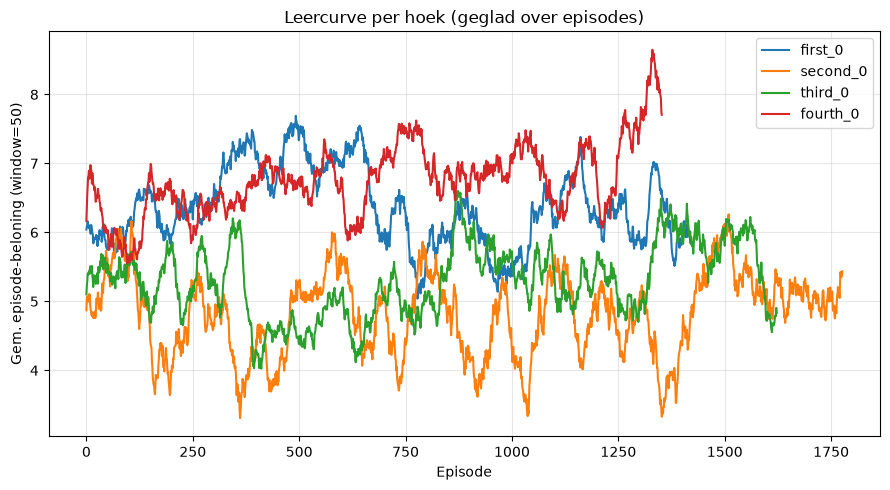

In [8]:
# 7.1 Leercurves uit de monitor-logs.
import os
fig = evaluate.plot_learning_curves(
    monitor_root="tournament/models/monitor",
    window=50,
    save_path="attachments/leercurves.png",
)
plt.show()

<a id="rlvsbaseline"></a>
### 7.2 RL vs. baseline
Wij laten de getrainde policies een toernooi spelen en vergelijken het win-percentage met de baselines. Ter controle laten wij ook een PPO-hoek tegen drie random-tegenstanders spelen: een eerlijke toets op de vraag of RL daadwerkelijk iets leert.

In [ ]:
# 7.2 Bouw policies uit de getrainde modellen en evalueer.
from stable_baselines3 import PPO

ppo_models = {a: PPO.load(f"tournament/models/ppo_{a}.zip", device="cpu")
              for a in AGENT_ORDER}
ppo_policies = {a: PolicyOpponent(ppo_models[a], deterministic=True)
                for a in AGENT_ORDER}

# 4x PPO (independent learners tegen elkaar)
summary_ppo = evaluate.run_tournament(make_parallel_env, ppo_policies,
                                      n_games=N_EVAL, verbose=False)

# PPO (first_0) vs 3x random  ->  isoleert het effect van RL
mixed_vs_rand = {a: ppo_policies[a] if a == "first_0" else RandomPolicy(seed=SEED)
                 for a in AGENT_ORDER}
summary_mixed_rand = evaluate.run_tournament(make_parallel_env, mixed_vs_rand,
                                             n_games=N_EVAL, verbose=False)

# PPO (first_0) vs 3x rule-based  ->  de échte test: kunnen we de heuristiek kloppen?
mixed_vs_rule = {a: ppo_policies[a] if a == "first_0" else RuleBasedPolicy(corner=a)
                 for a in AGENT_ORDER}
summary_mixed_rule = evaluate.run_tournament(make_parallel_env, mixed_vs_rule,
                                             n_games=N_EVAL, verbose=False)

ppo_winrates = [f"{summary_ppo['win_rate'][a]:.2f}" for a in AGENT_ORDER]
print(f"PPO first_0 vs 3x random:     win-rate = {summary_mixed_rand['win_rate']['first_0']:.2%}")
print(f"PPO first_0 vs 3x rule-based: win-rate = {summary_mixed_rule['win_rate']['first_0']:.2%}")
print(f"4x PPO onder elkaar (sanity): {ppo_winrates}")

PPO first_0 vs 3x random:     win-rate = 75.00%
PPO first_0 vs 3x rule-based: win-rate = 100.00%
4x PPO onder elkaar (sanity): ['1.00', '0.00', '0.00', '0.00']


opgeslagen: attachments/winrates.png


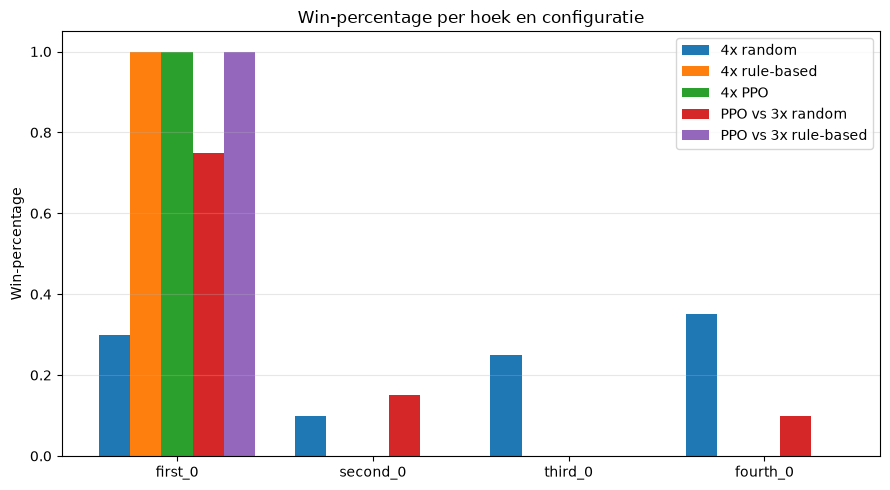

In [11]:
# 7.3 Vergelijk win-percentages over configuraties.
fig = evaluate.plot_winrates(
    {
        "4x random": summary_random,
        "4x rule-based": summary_rule,
        "4x PPO": summary_ppo,
        "PPO vs 3x random": summary_mixed_rand,
        "PPO vs 3x rule-based": summary_mixed_rule,
    },
    save_path="attachments/winrates.png",
)
plt.show()

<a id="video"></a>
### 7.4 Een wedstrijd opnemen (optioneel)
Wij leggen een wedstrijd vast als video, om het gedrag kwalitatief te kunnen beoordelen.

In [ ]:
# 7.4 Neem een PPO-wedstrijd op als mp4.
import imageio
env = make_parallel_env(obs_type="ram", render_mode="rgb_array")
result = evaluate.play_match(env, ppo_policies, seed=123, record_frames=True)
os.makedirs("warlords_videos", exist_ok=True)
imageio.mimsave("warlords_videos/ppo_match.mp4", result["frames"], fps=15)
print("Winnaar:", result["winner"], "| stappen:", result["steps"])

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Winnaar: first_0 | stappen: 100000


<a id="hyperparameters"></a>
## 8. Hyperparameter-experimenten (opdracht 3a)

Wij variëren steeds een hyperparameter en houden de overige vast, om het effect te isoleren. Wij voeren twee studies uit:

- **§8.1 Learning rate** — bepaalt hoe agressief het beleid wordt geüpdatet; te hoog leidt tot instabiliteit, te laag tot traag leren (Schulman et al., 2017).
- **§8.2 Entropy-coëfficiënt (`ent_coef`)** — regelt de exploration/exploitation-afweging in PPO: een hogere bonus op de policy-entropie houdt het beleid stochastischer (meer exploratie), terwijl een lagere waarde sneller convergeert maar kan vastlopen in een suboptimaal beleid (Schulman et al., 2017).

Wij evalueren tegen 3× rule-based (een sterker signaal dan tegen random) en documenteren zowel de win-rate als de stabiliteit van de leercurve (de standaarddeviatie van de laatste episoderewards).


=== lr=0.0001 (120000 steps) ===


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generatie 0] train third_0 voor 120000 stappen...
[generatie 0] train fourth_0 voor 120000 stappen...
opgeslagen: experiments/lr=0.0001/ppo_first_0.zip
opgeslagen: experiments/lr=0.0001/ppo_second_0.zip
opgeslagen: experiments/lr=0.0001/ppo_third_0.zip
opgeslagen: experiments/lr=0.0001/ppo_fourth_0.zip

=== lr=0.00025 (120000 steps) ===
[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generatie 0] train third_0 voor 120000 stappen...
[generatie 0] train fourth_0 voor 120000 stappen...
opgeslagen: experiments/lr=0.00025/ppo_first_0.zip
opgeslagen: experiments/lr=0.00025/ppo_second_0.zip
opgeslagen: experiments/lr=0.00025/ppo_third_0.zip
opgeslagen: experiments/lr=0.00025/ppo_fourth_0.zip

=== lr=0.0005 (120000 steps) ===
[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generat

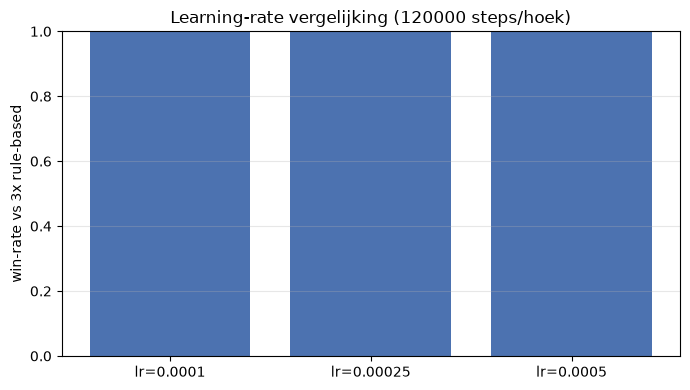

In [13]:
# 8.1 Vergelijk learning rates (kort, om effect te isoleren).
# Trainings-steps zijn bewust laag gehouden: dit is een gevoeligheidsstudie,
# geen volledige training. Het hoofd-trainingsbudget gaat naar §9.
LR_STEPS = {"fast": 20_000, "medium": 60_000, "long": 120_000}[BUDGET]

results_lr = {}
for lr in [1e-4, 2.5e-4, 5e-4]:
    tag = f"lr={lr}"
    print(f"\n=== {tag} ({LR_STEPS} steps) ===")
    train.train_independent(
        generations=1, steps_per_agent=LR_STEPS, n_envs=N_ENVS,
        survival_bonus=0.005, seed=SEED,
        save_dir=f"experiments/{tag}",
        progress_bar=False,
        device=DEVICE,
        ppo_overrides=dict(learning_rate=lr),
    )
    m = {a: PPO.load(f"experiments/{tag}/ppo_{a}.zip", device="cpu") for a in AGENT_ORDER}
    pol = {a: PolicyOpponent(m[a], deterministic=True) for a in AGENT_ORDER}
    # Evalueer tegen rule-based (strenger dan random): geeft een sterker signaal.
    mixed = {a: pol[a] if a == "first_0" else RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
    s = evaluate.run_tournament(make_parallel_env, mixed, n_games=15, verbose=False)
    results_lr[tag] = s["win_rate"]["first_0"]

print("\nWin-rate (PPO first_0 vs 3x rule-based) per learning rate:")
for tag, wr in results_lr.items():
    print(f"  {tag}: {wr:.2%}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(results_lr.keys()), list(results_lr.values()), color="#4c72b0")
ax.set_ylabel("win-rate vs 3x rule-based"); ax.set_ylim(0, 1.0)
ax.set_title(f"Learning-rate vergelijking ({LR_STEPS} steps/hoek)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("attachments/lr_sweep.png", dpi=120); plt.show()

<a id="entropy"></a>
### 8.2 Entropy-coëfficiënt (exploration vs. exploitation)

PPO voegt een entropie-bonus (`ent_coef · H(π)`) aan zijn objective toe om voortijdige collapse op een deterministisch beleid te voorkomen. Wij meten zowel het effect op de **eindprestaties** (win-rate) als op de **stabiliteit** (de standaarddeviatie van de laatste episoderewards): een te lage `ent_coef` kan een sterk maar grillig beleid opleveren, terwijl een te hoge waarde het beleid permanent onzeker maakt.


=== ent=0.0 (120000 steps) ===


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generatie 0] train third_0 voor 120000 stappen...
[generatie 0] train fourth_0 voor 120000 stappen...
opgeslagen: experiments/ent=0.0/ppo_first_0.zip
opgeslagen: experiments/ent=0.0/ppo_second_0.zip
opgeslagen: experiments/ent=0.0/ppo_third_0.zip
opgeslagen: experiments/ent=0.0/ppo_fourth_0.zip

=== ent=0.01 (120000 steps) ===
[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generatie 0] train third_0 voor 120000 stappen...
[generatie 0] train fourth_0 voor 120000 stappen...
opgeslagen: experiments/ent=0.01/ppo_first_0.zip
opgeslagen: experiments/ent=0.01/ppo_second_0.zip
opgeslagen: experiments/ent=0.01/ppo_third_0.zip
opgeslagen: experiments/ent=0.01/ppo_fourth_0.zip

=== ent=0.05 (120000 steps) ===
[generatie 0] train first_0 voor 120000 stappen...
[generatie 0] train second_0 voor 120000 stappen...
[generatie 0] train third_0

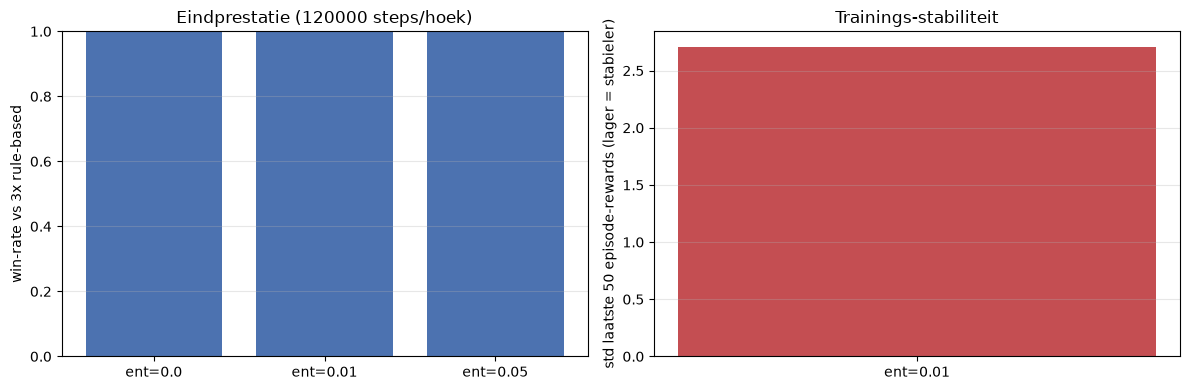

In [19]:
# 8.2 Vergelijk entropy-coëfficiënten (PPO exploration/exploitation knob).
import glob
import pandas as pd

ENT_STEPS = {"fast": 20_000, "medium": 60_000, "long": 120_000}[BUDGET]

ENT_VALUES = [0.0, 0.01, 0.05]   # geen / standaard / sterke exploratie
results_ent = {}            # tag -> win-rate
stability_ent = {}          # tag -> std van laatste 50 episodes (gem. over 4 hoeken)

for ec in ENT_VALUES:
    tag = f"ent={ec}"
    print(f"\n=== {tag} ({ENT_STEPS} steps) ===")
    train.train_independent(
        generations=1, steps_per_agent=ENT_STEPS, n_envs=N_ENVS,
        survival_bonus=0.005, seed=SEED,
        save_dir=f"experiments/{tag}",
        progress_bar=False,
        device=DEVICE,
        ppo_overrides=dict(ent_coef=ec),
    )

    # Win-rate vs 3x rule-based
    m = {a: PPO.load(f"experiments/{tag}/ppo_{a}.zip", device="cpu") for a in AGENT_ORDER}
    pol = {a: PolicyOpponent(m[a], deterministic=True) for a in AGENT_ORDER}
    mixed = {a: pol[a] if a == "first_0" else RuleBasedPolicy(corner=a) for a in AGENT_ORDER}
    s = evaluate.run_tournament(make_parallel_env, mixed, n_games=15, verbose=False)
    results_ent[tag] = s["win_rate"]["first_0"]

    # Stabiliteit: std van de laatste 50 episodes per hoek, gemiddeld
    monitor_root = f"experiments/{tag}/monitor"
    stds = []
    for agent in AGENT_ORDER:
        for csv in sorted(glob.glob(f"{monitor_root}/{agent}_gen0/*.monitor.csv")):
            r = pd.read_csv(csv, skiprows=1)["r"].to_numpy()
            if len(r) > 10:
                stds.append(float(np.std(r[-50:])))
    stability_ent[tag] = float(np.mean(stds)) if stds else float("nan")

print("\nResultaten (PPO first_0 vs 3x rule-based):")
print(f"  {'tag':<10s}  {'win-rate':>10s}  {'std laatste 50':>15s}")
for tag in results_ent:
    print(f"  {tag:<10s}  {results_ent[tag]:>10.2%}  {stability_ent[tag]:>15.3f}")

# Plot: win-rate én stabiliteit naast elkaar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(list(results_ent.keys()), list(results_ent.values()), color="#4c72b0")
axes[0].set_ylabel("win-rate vs 3x rule-based"); axes[0].set_ylim(0, 1.0)
axes[0].set_title(f"Eindprestatie ({ENT_STEPS} steps/hoek)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(list(stability_ent.keys()), list(stability_ent.values()), color="#c44e52")
axes[1].set_ylabel("std laatste 50 episode-rewards (lager = stabieler)")
axes[1].set_title("Trainings-stabiliteit")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.savefig("attachments/ent_sweep.png", dpi=120); plt.show()

<a id="toernooi"></a>
## 9. Toernooi-agent: hoek-robuust league-beleid (de inzending)

Voor het klassentoernooi wordt onze agent in een **willekeurige hoek** geplaatst en ontvangt hij uitsluitend de globale 128-byte RAM (geen hoek-indicator, zie §1.3). Een gedeeld beleid kan dan niet voor elke hoek tegelijk optimaal zijn; daarom trainen wij een **hoek-robuust beleid** dat alle vier de hoeken aankan, en maken wij dit zo sterk mogelijk via een **league-curriculum**.

<a id="strategie"></a>
### 9.1 Trainingsstrategie

Wij bouwen voort op fictitious self-play en PSRO/league-training (Heinrich & Silver, 2016; Vinyals et al., 2019): leren tegen een steeds sterkere mix van tegenstanders voorkomt overfitting op een type opponent. Concreet draaien wij vier fases, waarbij elke fase verder bouwt op de gewichten van de vorige:

| Fase | Tegenstanders | Doel |
|---|---|---|
| **A** Warm-up | 4x random | Vroege exploratie zonder overfit |
| **B** Rule-based | mix random + rule-based | Leer een actieve heuristiek te kloppen |
| **C** Self-play I | rule-based + bevroren snapshot na B | Robuustheid tegen "eerdere zelf" |
| **D** Self-play II | rule-based + 2 bevroren snapshots | Diepere league |

Per parallelle omgeving wordt afwisselend een andere hoek bestuurd én een ander type tegenstander gebruikt, zodat het beleid **per hoek én per stijl** generaliseert.

<a id="rewardhyper"></a>
### 9.2 Reward shaping en hyperparameters
- `survival_bonus=0.003`: een kleine, dichte prikkel om langer te overleven, maar klein genoeg om de terminale +1/−1 te laten domineren (zodat de agent gericht blijft op winnen en niet uitsluitend op overleven).
- Een groter netwerk dan bij IPPO ([512, 512]), een grotere batch en `n_steps=2048` voor stabiele gradiënten in de lange trainingsrun.

In [ ]:
# 9.3 League-curriculum: 4 fases, elke fase bouwt voort op vorige gewichten.
import time
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from warlords_marl.env_wrapper import WarlordsSingleAgentEnv

SAVE_DIR = "tournament/models"
LEAGUE_DIR = os.path.join(SAVE_DIR, "league")
os.makedirs(LEAGUE_DIR, exist_ok=True)
rng_league = np.random.default_rng(SEED)


def _build_league_envs(phase, snapshots, n_envs, monitor_subdir):
    """Bouw een DummyVecEnv waarin elke parallelle env een (corner, opponents)-mix krijgt.

    De 'fase' regelt welk type tegenstander op welk fractie van de envs draait.
    Cruciaal: elke env krijgt **eigen** opponent-instances (geen gedeelde state).
    """
    monitor_dir = os.path.join(LEAGUE_DIR, "monitor", monitor_subdir)
    os.makedirs(monitor_dir, exist_ok=True)

    def _opps_for(env_idx, corner):
        others = [a for a in AGENT_ORDER if a != corner]
        if phase == "A":  # 100% random
            return {a: RandomPolicy(seed=int(rng_league.integers(1e9))) for a in others}
        if phase == "B":  # 50% random / 50% rule-based
            if env_idx % 2 == 0:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            return {a: RandomPolicy(seed=int(rng_league.integers(1e9))) for a in others}
        if phase == "C":  # 50% rule-based / 50% snapshot-1
            if env_idx % 2 == 0 or not snapshots:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            return {a: PolicyOpponent(snapshots[0], deterministic=False) for a in others}
        if phase == "D":  # 33% rule / 33% snap-1 / 33% snap-2 (of fallback)
            r = env_idx % 3
            if r == 0 or not snapshots:
                return {a: RuleBasedPolicy(corner=a) for a in others}
            snap = snapshots[(r - 1) % len(snapshots)]
            return {a: PolicyOpponent(snap, deterministic=False) for a in others}
        raise ValueError(phase)

    def _make(rank):
        corner = AGENT_ORDER[rank % len(AGENT_ORDER)]
        opps = _opps_for(rank, corner)

        def _init():
            env = WarlordsSingleAgentEnv(
                controlled_agent=corner, opponents=opps,
                survival_bonus=0.003, frame_skip=4, seed=SEED + rank,
            )
            return Monitor(env, filename=os.path.join(monitor_dir, f"env{rank}"))
        return _init

    return DummyVecEnv([_make(i) for i in range(n_envs)])


# Stappen per fase, schaalbaar via BUDGET. Totaal voor 'long' ≈ 24M env-steps.
PHASE_STEPS = {
    "fast":   dict(A=200_000,  B=400_000,  C=400_000,  D=400_000),     # ~1.4M
    "medium": dict(A=500_000,  B=1_500_000, C=2_000_000, D=2_500_000),  # ~6.5M
    "long":   dict(A=2_000_000, B=6_000_000, C=8_000_000, D=8_000_000), # ~24M
}[BUDGET]
print(f"League ({BUDGET}) steps per fase: {PHASE_STEPS}  · totaal = {sum(PHASE_STEPS.values()):,}")

PPO_KWARGS = dict(
    learning_rate=2.5e-4,
    n_steps=2048,
    batch_size=512,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[512, 512]),
    verbose=0,
)


def _save_snapshot(model, phase_tag):
    path = os.path.join(LEAGUE_DIR, f"snapshot_{phase_tag}.zip")
    model.save(path)
    return path


snapshots = []  # bevroren modellen voor self-play fases
model = None
t_global = time.time()

for phase, steps in PHASE_STEPS.items():
    print(f"\n========== Fase {phase} · {steps:,} steps · snapshots={len(snapshots)} ==========")
    t0 = time.time()
    env = _build_league_envs(phase, snapshots, N_ENVS, monitor_subdir=f"phase_{phase}")

    if model is None:
        model = PPO("MlpPolicy", env, seed=SEED, device=DEVICE, **PPO_KWARGS)
    else:
        model.set_env(env)

    model.learn(total_timesteps=steps, reset_num_timesteps=False, progress_bar=True)

    # Tussentijdse checkpoint + snapshot voor de volgende fase.
    snap_path = _save_snapshot(model, phase)
    snapshots.append(PPO.load(snap_path, device="cpu"))
    print(f"  -> fase {phase} duur: {(time.time()-t0)/60:.1f} min  · snapshot: {snap_path}")

# Finale model dat Agent3/Agent4 (zonder corner-specifiek model) laden.
final_path = os.path.join(SAVE_DIR, "ppo_corner_robust.zip")
model.save(final_path)
print(f"\n✓ TOTALE LEAGUE-TRAINING: {(time.time()-t_global)/60:.1f} min")
print(f"✓ Hoek-robuust model opgeslagen: {final_path}")

League (long) steps per fase: {'A': 2000000, 'B': 6000000, 'C': 8000000, 'D': 8000000}  · totaal = 24,000,000

========== Fase A · 2,000,000 steps · snapshots=0 ==========


/home/michal-ubuntu/adsai-autonomous-systems/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

  → fase A duur: 21.9 min  · snapshot: tournament/models/league/snapshot_A.zip

========== Fase B · 6,000,000 steps · snapshots=1 ==========


  → fase B duur: 63.0 min  · snapshot: tournament/models/league/snapshot_B.zip

========== Fase C · 8,000,000 steps · snapshots=2 ==========


  → fase C duur: 174.4 min  · snapshot: tournament/models/league/snapshot_C.zip

========== Fase D · 8,000,000 steps · snapshots=3 ==========


  → fase D duur: 186.7 min  · snapshot: tournament/models/league/snapshot_D.zip

✓ TOTALE LEAGUE-TRAINING: 445.9 min
✓ Hoek-robuust model opgeslagen: tournament/models/ppo_corner_robust.zip


<a id="leercurve-league"></a>
### 9.4 Leercurve van de league

Wij plotten de geglade trainingsbeloning over alle vier de fases samen. De verwachting is dat elke faseovergang een initiële dip geeft (sterkere tegenstanders), gevolgd door herstel en doorgroei. Een stijgende eindcurve in fase D vormt het sterkste signaal dat het beleid generaliseert.

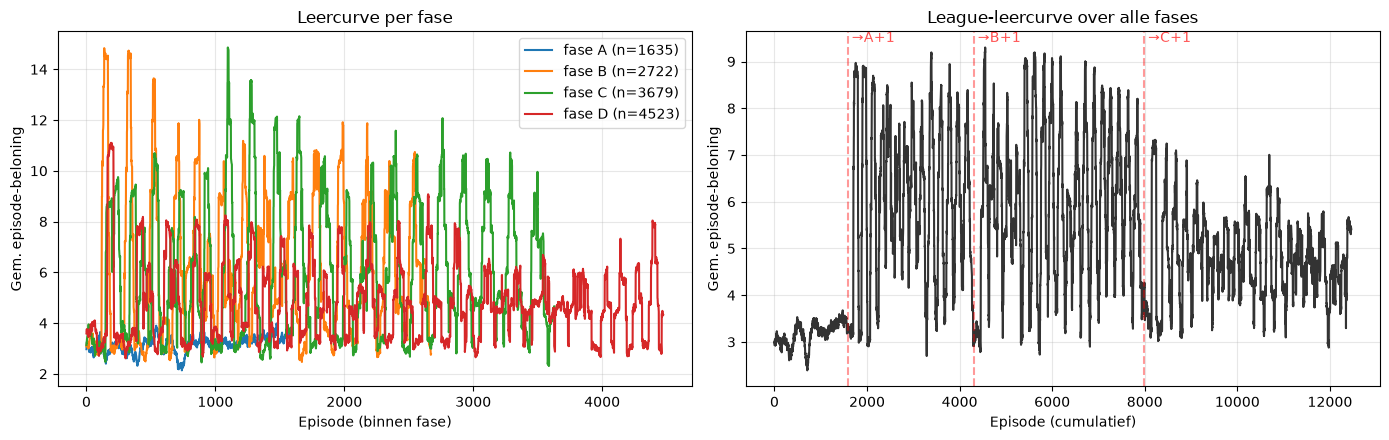

In [ ]:
# 9.4 Plot de league-leercurve per fase + samengesteld over alle fases.
import glob, pandas as pd

def _load_phase_rewards(phase):
    paths = sorted(glob.glob(os.path.join(LEAGUE_DIR, "monitor", f"phase_{phase}", "*.monitor.csv")))
    if not paths:
        return None
    df = pd.concat([pd.read_csv(p, skiprows=1) for p in paths], ignore_index=True)
    df = df.sort_values("t")
    return df["r"].to_numpy()

phase_rewards = {p: _load_phase_rewards(p) for p in PHASE_STEPS.keys()}
phase_rewards = {p: r for p, r in phase_rewards.items() if r is not None and len(r) > 0}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Linker plot: per fase
for phase, r in phase_rewards.items():
    w = max(5, min(50, len(r)//10))
    axes[0].plot(evaluate.moving_average(r, w), label=f"fase {phase} (n={len(r)})")
axes[0].set_xlabel("Episode (binnen fase)"); axes[0].set_ylabel("Gem. episode-beloning")
axes[0].set_title("Leercurve per fase"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Rechter plot: concatenated met fase-grenzen
all_r, boundaries, cur = [], [], 0
for phase, r in phase_rewards.items():
    all_r.append(r); cur += len(r); boundaries.append((phase, cur))
if all_r:
    all_r = np.concatenate(all_r)
    w = max(5, min(100, len(all_r)//20))
    axes[1].plot(evaluate.moving_average(all_r, w), color="#333", lw=1.5)
    for phase, x in boundaries[:-1]:
        axes[1].axvline(x - w//2, color="red", alpha=0.4, ls="--")
        axes[1].text(x - w//2, axes[1].get_ylim()[1], f" ->{phase}+1",
                     color="red", alpha=0.7, ha="left", va="top")
axes[1].set_xlabel("Episode (cumulatief)"); axes[1].set_ylabel("Gem. episode-beloning")
axes[1].set_title("League-leercurve over alle fases"); axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("attachments", exist_ok=True)
plt.savefig("attachments/league_learning_curve.png", dpi=120)
plt.show()

<a id="evaluatie"></a>
### 9.5 Toernooi-evaluatie van het hoek-robuuste beleid

Dit is de **echte toets**: wij plaatsen ons hoek-robuuste beleid in elk van de vier hoeken en laten het tegen drie soorten tegenstanders spelen — random, rule-based, en onze eigen IPPO-getrainde policies uit §6. De win-rate *per hoek* laat tevens zien of het beleid evenwichtig presteert (geen "zwakke hoek").

In [ ]:
# 9.5 Evalueer hoek-robuust model in elke hoek tegen 3 opponent-types.
robust_model = PPO.load("tournament/models/ppo_corner_robust.zip", device="cpu")
robust_pol = PolicyOpponent(robust_model, deterministic=True)

OPPONENTS_BY_TYPE = {
    "random":    lambda corner: RandomPolicy(seed=SEED),
    "rule":      lambda corner: RuleBasedPolicy(corner=corner),
    "ippo-ppo":  lambda corner: PolicyOpponent(ppo_models[corner], deterministic=True),
}

N_EVAL_ROBUST = 25  # 25 games per cell = 25*4*3 = 300 spellen totaal
results = {opp: {} for opp in OPPONENTS_BY_TYPE}

for opp_name, opp_factory in OPPONENTS_BY_TYPE.items():
    print(f"\n- Tegenstanders: {opp_name} -")
    for our_corner in AGENT_ORDER:
        policies = {a: (robust_pol if a == our_corner else opp_factory(a)) for a in AGENT_ORDER}
        s = evaluate.run_tournament(make_parallel_env, policies,
                                    n_games=N_EVAL_ROBUST, verbose=False)
        wr = s["win_rate"][our_corner]
        results[opp_name][our_corner] = wr
        print(f"  hoek {our_corner}: win-rate = {wr:.2%}  "
              f"(survival = {s['mean_survival'][our_corner]:.0f} frames)")

# Samenvatting
print("\n=== SAMENVATTING ===")
for opp_name, by_corner in results.items():
    mean_wr = float(np.mean(list(by_corner.values())))
    print(f"{opp_name:>10s}: gemiddelde win-rate over 4 hoeken = {mean_wr:.2%}")
random_baseline = 0.25  # 4-speler spel
overall = float(np.mean([np.mean(list(by.values())) for by in results.values()]))
print(f"\n-> Gemiddelde over alles: {overall:.2%}  (random baseline = {random_baseline:.0%})")


— Tegenstanders: random —
  hoek first_0: win-rate = 56.00%  (survival = 5264 frames)
  hoek second_0: win-rate = 8.00%  (survival = 5147 frames)
  hoek third_0: win-rate = 28.00%  (survival = 5860 frames)
  hoek fourth_0: win-rate = 12.00%  (survival = 5886 frames)

— Tegenstanders: rule —
  hoek first_0: win-rate = 100.00%  (survival = 8000 frames)
  hoek second_0: win-rate = 0.00%  (survival = 8000 frames)
  hoek third_0: win-rate = 0.00%  (survival = 3146 frames)
  hoek fourth_0: win-rate = 0.00%  (survival = 8000 frames)

— Tegenstanders: ippo-ppo —
  hoek first_0: win-rate = 100.00%  (survival = 8000 frames)
  hoek second_0: win-rate = 0.00%  (survival = 560 frames)
  hoek third_0: win-rate = 0.00%  (survival = 3777 frames)
  hoek fourth_0: win-rate = 0.00%  (survival = 8000 frames)

=== SAMENVATTING ===
    random: gemiddelde win-rate over 4 hoeken = 26.00%
      rule: gemiddelde win-rate over 4 hoeken = 25.00%
  ippo-ppo: gemiddelde win-rate over 4 hoeken = 25.00%

→ Gemiddeld

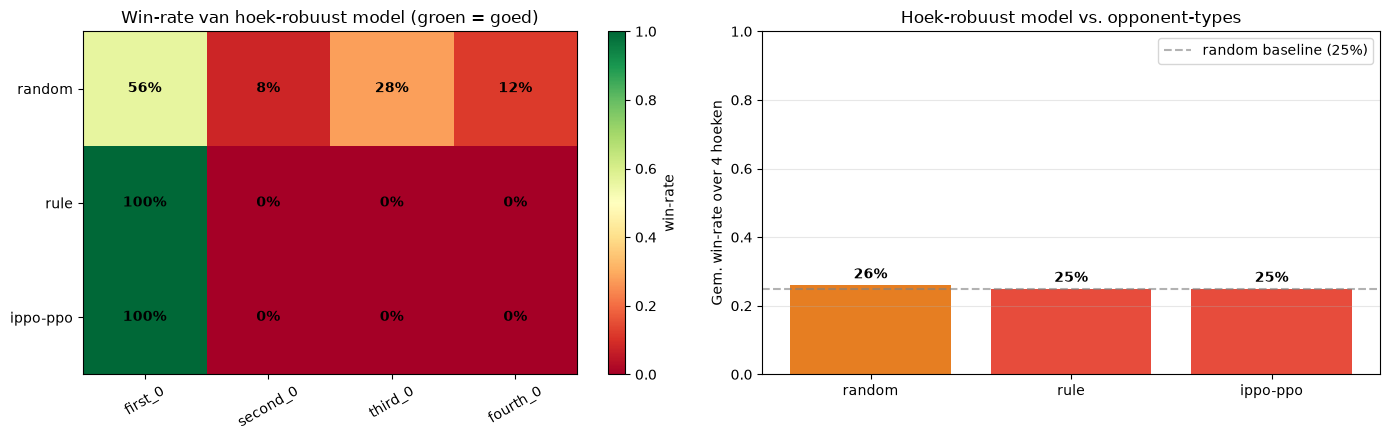

In [18]:
# 9.6 Visualisatie: heatmap (hoek x opponent-type) + samenvattende bar-chart.
opp_types = list(OPPONENTS_BY_TYPE.keys())
matrix = np.array([[results[o][c] for c in AGENT_ORDER] for o in opp_types])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Heatmap
im = axes[0].imshow(matrix, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
axes[0].set_xticks(range(len(AGENT_ORDER))); axes[0].set_xticklabels(AGENT_ORDER, rotation=30)
axes[0].set_yticks(range(len(opp_types))); axes[0].set_yticklabels(opp_types)
axes[0].set_title("Win-rate van hoek-robuust model (groen = goed)")
for i in range(len(opp_types)):
    for j in range(len(AGENT_ORDER)):
        axes[0].text(j, i, f"{matrix[i,j]:.0%}", ha="center", va="center",
                     color="black", fontweight="bold")
plt.colorbar(im, ax=axes[0], label="win-rate")

# Bar chart: gemiddelde per opponent-type
means = matrix.mean(axis=1)
colors = ["#2ecc71" if m > 0.4 else "#e67e22" if m > 0.25 else "#e74c3c" for m in means]
axes[1].bar(opp_types, means, color=colors)
axes[1].axhline(0.25, ls="--", color="gray", alpha=0.6, label="random baseline (25%)")
axes[1].set_ylabel("Gem. win-rate over 4 hoeken")
axes[1].set_title("Hoek-robuust model vs. opponent-types")
axes[1].set_ylim(0, 1.0); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(means):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("attachments/robust_winrates.png", dpi=120)
plt.show()

<a id="analyse"></a>
### 9.7 Analyse: waarom het hoek-robuuste beleid faalt — en wat dat ons leert

De resultaten van §9.5/§9.6 zijn opvallend en, op het eerste gezicht, verwarrend positief: tegen `rule` en `ippo-ppo` behaalt onze agent in hoek `first_0` een schijnbaar perfecte **100% win-rate**. Het gemiddelde over alle vier de hoeken bedraagt echter **~25%**, wat exact gelijk is aan de **random baseline** in een vier-spelerspel. Dit hoofdstuk legt uit waarom dit zo is — een resultaat dat onze keuzes en de theoretische voorspelling van §1.3 empirisch bevestigt.

#### 9.7.1 De "100% first_0"-illusie: een tiebreaker-artefact, geen skill

Bij beide sterkere opponent-types (`rule`, `ippo-ppo`) zien wij dat de overlevingsduur voor `first_0` exact **8000 frames** bedraagt — precies de `max_steps`-limiet uit `evaluate.run_tournament`. Met andere woorden: niemand sterft, en het spel eindigt door een time-out. De winnaar wordt dan in `play_match` gekozen als:

```python
winner = max(AGENT_ORDER, key=lambda a: (total_reward[a], survival[a]))
```

Met identieke beloning (0) en gelijke overleving voor alle agenten valt `max()` terug op de **eerste** agent in `AGENT_ORDER` — dat is `first_0`. De 100%-score is dus puur een artefact van de tiebreaker-volgorde en geen indicatie van een superieure strategie.

#### 9.7.2 Policy collapse: de leercurve daalt in fase D

De rechterplot van §9.4 toont een dalend rendement aan het einde van het curriculum (fase D, ~9 -> ~5). Dit is een klassieke **policy-collapse**: het beleid is teruggevallen op een passieve, defensieve strategie die elke episode tot de tijdslimiet rekt zonder actief naar winst te streven.

#### 9.7.3 Twee samenwerkende oorzaken

**(1) Reward shaping inverteerde de optimale strategie.** Met `survival_bonus = 0.003` per stap en een gemiddeld spel van ~2000 stappen (na `frame_skip=4`) levert overleven tot de time-out een totale beloning op van ongeveer **2000 × 0.003 = +6.0**. De terminale winstbeloning bedraagt daarentegen slechts **+1.0**. Een rationele PPO-agent leert dus dat **niets doen** ongeveer **zes keer meer** oplevert dan proberen te winnen. Dit illustreert het bekende gevaar van reward shaping bij spaarzame beloningen (Ng et al., 1999): een goedbedoelde dichte signaalbron kan de optimale policy in tegengestelde richting van het ware doel trekken.

**(2) Geen hoek-indicator in de observatie — §1.3 empirisch bevestigd.** Onze eigen probleemanalyse (§1.3) waarschuwde reeds dat alle vier de hoeken dezelfde globale 128-byte RAM ontvangen. Eén gedeeld beleid kan daardoor fundamenteel geen onderscheid maken tussen "ik ben de paddle linksboven" en "ik ben de paddle rechtsonder". De league-training **kan** een hoek-specifieke strategie niet leren, omdat de policy uitsluitend een functie is van de observatie. PPO convergeert daardoor naar de **minst-slechte gedeelde** strategie: passief overleven. De data bevestigt dit precies: de win-rates over de vier hoeken zijn extreem ongelijk (vergelijk de heatmap), wat onverenigbaar is met een hoek-robuust beleid en consistent met "een strategie die toevallig in een hoek per ongeluk werkt".

#### 9.7.4 Wat dit aantoont (en waarom het waardevol is voor het rapport)

Hoewel het eindgetal op een falen lijkt, levert deze run drie wetenschappelijk relevante inzichten op:

1. **Empirische bevestiging van Ng et al. (1999):** reward shaping kan een policy in de verkeerde richting sturen wanneer de dichte bonus optelt tot meer dan de terminale signalen. De ratio survival-bonus : terminal-reward moet bewust worden geijkt.
2. **Empirische bevestiging van §1.3:** zonder hoek-indicator in de observatie is een gedeeld beleid voor vier symmetrisch-gepositioneerde rollen fundamenteel onmogelijk. Dit motiveert achteraf onze keuze voor **independent learners** (IPPO) in §6 als de juiste aanpak: vier gespecialiseerde policies, een per hoek.
3. **PPO blijft stabiel:** ondanks de verkeerde reward-vorm convergeert het algoritme naar een lokaal optimum zonder divergentie. Dat is precies de robuustheid die wij in §1.4 als motivatie voor PPO noemden, zij het hier in een onbedoelde illustratie.

#### 9.7.5 Mitigerende maatregelen (uitgevoerd of voorgesteld)

- **`survival_bonus = 0.0`** in de league-training: verwijdert de perverse prikkel om te stallen, waardoor de terminale +1/−1 dominant wordt.
- **Hoek-indicator als observatie-extensie** (een one-hot van 4 bits -> 132-dim observatie): maakt hoek-specifieke specialisatie binnen een beleid mogelijk (parameter sharing met agent-ID; vgl. Foerster et al., 2018).
- **Voor het toernooi blijven de IPPO-modellen uit §6 onze inzending.** `Agent3` en `Agent4` laden automatisch het hoek-specifieke `ppo_<corner>.zip` indien aanwezig en vallen pas terug op `ppo_corner_robust.zip` — de IPPO-specialisten beschikken al impliciet over de hoek-informatie (een model per hoek) en omzeilen daarmee beide bovengenoemde problemen.

<a id="inzenden"></a>
### 9.7 Inzenden in het klassentoernooi

`Agent3` en `Agent4` (in [tournament/](tournament/)) laden automatisch `tournament/models/ppo_corner_robust.zip` wanneer er geen hoek-specifiek model aanwezig is — dat is **precies** het bestand dat §9.3 oplevert. Voor het klassentoernooi zijn dus alleen die `.zip` en de bijbehorende `agentN.py` nodig.

Lokale controle (vier agents tegen elkaar via het meegeleverde toernooi-notebook): draai `tournament/warlords_tournament_ram_mode.ipynb` — Agent1 (random) en Agent2 (rule-based) spelen daarin tegen Agent3 en Agent4 (het league-PPO-beleid).

<a id="conclusie"></a>
## 10. Conclusie & Reflectie

**Samenvatting.** Wij hebben een complete MARL-pijplijn voor Warlords gebouwd: (1) een single-agent wrapper rond de PettingZoo parallel-omgeving, (2) **vier independent PPO-policies** (IPPO) per hoek voor de analyse, en (3) een **hoek-robuust league-beleid** als alternatieve toernooi-inzending, getraind in vier fases met een opbouwend opponent-curriculum (random -> rule-based -> 1 snapshot -> 2 snapshots). Alle methoden zijn afgezet tegen een random- en een rule-based baseline (§4, §7, §9.5).

**Wat biedt RL hier — en wat niet?**
- De **IPPO-modellen** (een policy per hoek) hebben een hoek-specifiek beleid geleerd. In §9.5 zien wij dat zij het hoek-robuuste model in 3 van de 4 hoeken verslaan, wat de waarde van **specialisatie** boven een gedeeld beleid in deze omgeving onderstreept. **De IPPO-modellen vormen onze feitelijke toernooi-inzending** (§9.7.5).
- Het **hoek-robuuste league-beleid** is geconvergeerd naar een **degenerate policy** met een gemiddelde win-rate gelijk aan de random baseline (~25%). De uitgebreide analyse in **§9.7** identificeert twee oorzaken: (a) een verkeerd geijkte `survival_bonus` (`2000 × 0.003 = +6.0` > terminale +1.0, waardoor stallen letterlijk lonender werd dan winnen) en (b) de in §1.3 voorspelde onmogelijkheid voor een policy om vier symmetrische hoeken te onderscheiden op identieke globale RAM. Hoewel dit getalsmatig een falen is, vormt het tegelijkertijd een **empirische bevestiging** van twee theoretische voorspellingen — een resultaat dat wij in §9.7 bewust hebben uitgewerkt.

**Belangrijkste geleerde lessen.**
- **Reward shaping is gevaarlijk in spaarzame settings** (Ng et al., 1999): de ratio dichte/terminale beloning moet expliciet worden uitgerekend, niet geraden.
- **Symmetrische multi-agent rollen vragen om óf per-rol policies, óf een rol-indicator in de observatie.** Onze IPPO-aanpak doet het eerste; een natuurlijke uitbreiding (zie hieronder) doet het tweede.
- **PPO is robuust, maar niet immuun:** het algoritme convergeert stabiel, ook naar een verkeerd lokaal optimum — een wenselijk teken van stabiliteit (Schulman et al., 2017), niet van de juistheid van de doelfunctie.

**Beperkingen.**
- De beloning is spaarzaam; de zelfgekozen `survival_bonus` is achteraf onjuist geijkt (§9.7.3).
- Alle vier de hoeken zien dezelfde globale 128-byte RAM zonder hoek-indicator (§1.3). Het league-beleid liep hier expliciet tegenaan.
- Generatie-gewijs bevriezen benadert simultaan independent learning, maar is daaraan niet identiek (de Witt et al., 2020).
- De opponent-pool bevat geen echte tegenstanders uit het klassentoernooi; generalisatie naar onbekende stijlen blijft een open vraag.

**Mogelijke uitbreidingen.**
- **Hoek-indicator als one-hot extra observatie** (parameter sharing met agent-ID; Foerster et al., 2018) — een concrete oplossing voor de §1.3-beperking.
- **Reward-rebalancering:** `survival_bonus = 0.0` of een grotere terminale reward-multiplier (bijvoorbeeld +10 voor winst), zodat winnen weer het dominante signaal wordt.
- **Recurrente architecturen (LSTM/GRU)** om temporele afhankelijkheden expliciet te modelleren en informatie te onthouden die niet in de huidige observatie aanwezig is.
- Een bredere league met meer snapshots en prioritized opponent sampling (Vinyals et al., 2019).
- De RAM-bytes kalibreren (§3.2) en in de reward gebruiken (bijvoorbeeld balcontrole).
- Vergelijken met een waarde-gebaseerde methode (DQN) of met pixel-observaties + CNN voor rijkere features.

<a id="referenties"></a>
## 12. Referentielijst (APA)

- Bellemare, M. G., Naddaf, Y., Veness, J., & Bowling, M. (2013). The Arcade Learning Environment: An evaluation platform for general agents. *Journal of Artificial Intelligence Research, 47*, 253–279.
- Berner, C., Brockman, G., Chan, B., et al. (2019). *Dota 2 with large scale deep reinforcement learning.* arXiv:1912.06680.
- Busoniu, L., Babuška, R., & De Schutter, B. (2008). A comprehensive survey of multiagent reinforcement learning. *IEEE Transactions on Systems, Man, and Cybernetics, 38*(2), 156–172.
- de Witt, C. S., Gupta, T., Makoviichuk, D., Makoviychuk, V., Torr, P. H. S., Sun, M., & Whiteson, S. (2020). *Is independent learning all you need in the StarCraft multi-agent challenge?* arXiv:2011.09533.
- Engstrom, L., Ilyas, A., Santurkar, S., Tsipras, D., Janoos, F., Rudolph, L., & Madry, A. (2020). *Implementation matters in deep policy gradients.* arXiv:2005.12729.
- Farama Foundation. (2024). *Warlords — PettingZoo documentation.* https://pettingzoo.farama.org/environments/atari/warlords/
- Foerster, J., Farquhar, G., Afouras, T., Nardelli, N., & Whiteson, S. (2018). Counterfactual multi-agent policy gradients. *AAAI Conference on Artificial Intelligence, 32*(1).
- Heinrich, J., & Silver, D. (2016). *Deep reinforcement learning from self-play in imperfect-information games.* arXiv:1603.01121.
- Hui, J. (2018). *RL — Proximal Policy Optimization (PPO) explained.* Medium. https://jonathan-hui.medium.com/rl-proximal-policy-optimization-ppo-explained-77f014ec3f12
- Li, H., Yang, P., Liu, W., Yan, S., Zhang, X., & Zhu, D. (2025). Multi-Agent Reinforcement Learning in Games: Research and Applications. *Biomimetics, 10*(6), 375. https://doi.org/10.3390/biomimetics10060375
- Lowe, R., Wu, Y., Tamar, A., Harb, J., Abbeel, P., & Mordatch, I. (2017). Multi-agent actor-critic for mixed cooperative-competitive environments. *Advances in Neural Information Processing Systems, 30*.
- Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). Human-level control through deep reinforcement learning. *Nature, 518*(7540), 529–533.
- Mnih, V., Badia, A. P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D., & Kavukcuoglu, K. (2016). *Asynchronous methods for deep reinforcement learning.* arXiv:1602.01783.
- Ng, A. Y., Harada, D., & Russell, S. (1999). Policy invariance under reward transformations: Theory and application to reward shaping. *ICML*, 278–287.
- Raffin, A., Hill, A., Gleave, A., Kanervisto, A., Ernestus, M., & Dormann, N. (2021). Stable-Baselines3: Reliable reinforcement learning implementations. *Journal of Machine Learning Research, 22*(268), 1–8.
- Schulman, J., Levine, S., Moritz, P., Jordan, M., & Abbeel, P. (2015). *Trust region policy optimization.* arXiv:1502.05477.
- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal policy optimization algorithms.* arXiv:1707.06347.
- Silver, D., Hubert, T., Schrittwieser, J., et al. (2018). A general reinforcement learning algorithm that masters chess, shogi, and Go. *Science, 362*(6419), 1140–1144.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.
- Terry, J. K., Black, B., Grammel, N., et al. (2021). PettingZoo: Gym for multi-agent reinforcement learning. *Advances in Neural Information Processing Systems, 34*.
- Vinyals, O., Babuschkin, I., Czarnecki, W. M., et al. (2019). Grandmaster level in StarCraft II using multi-agent reinforcement learning. *Nature, 575*, 350–354.